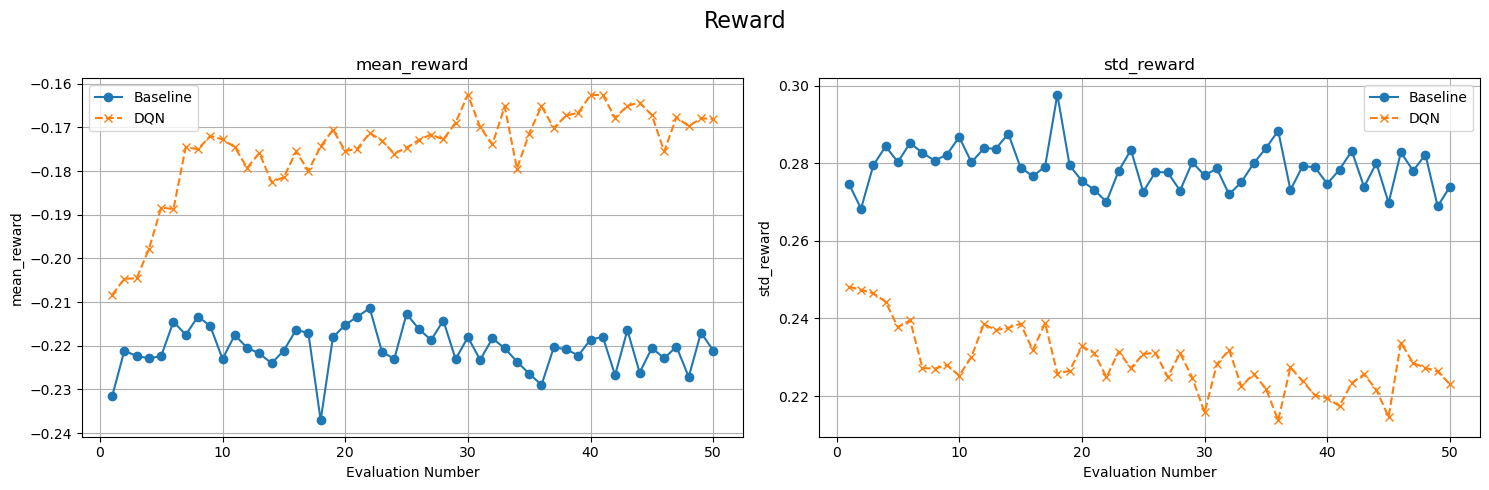

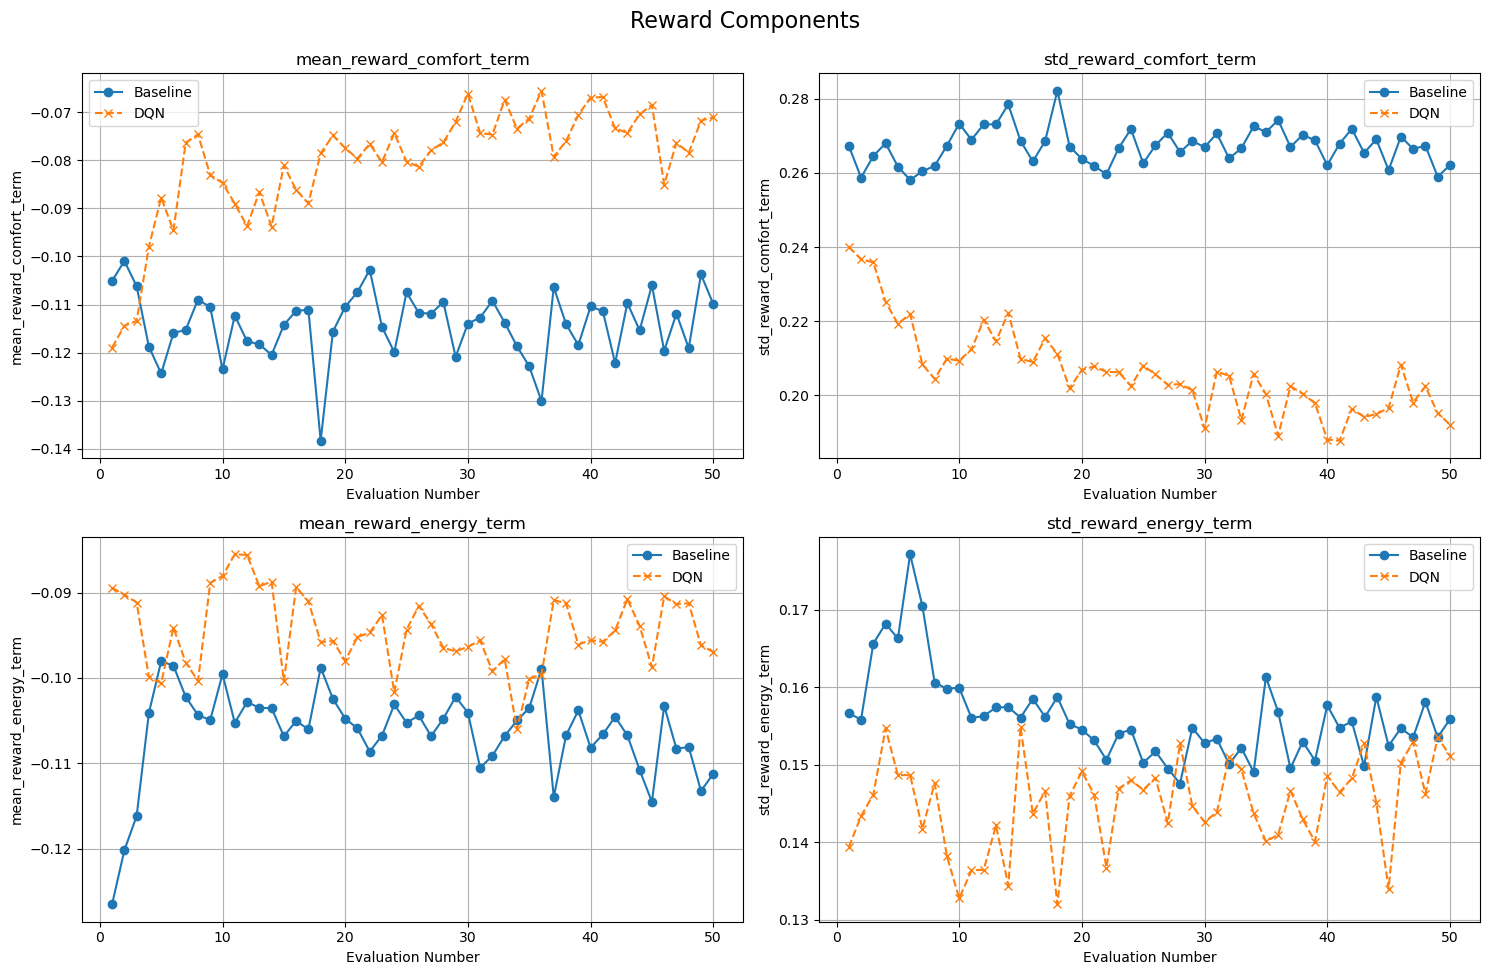

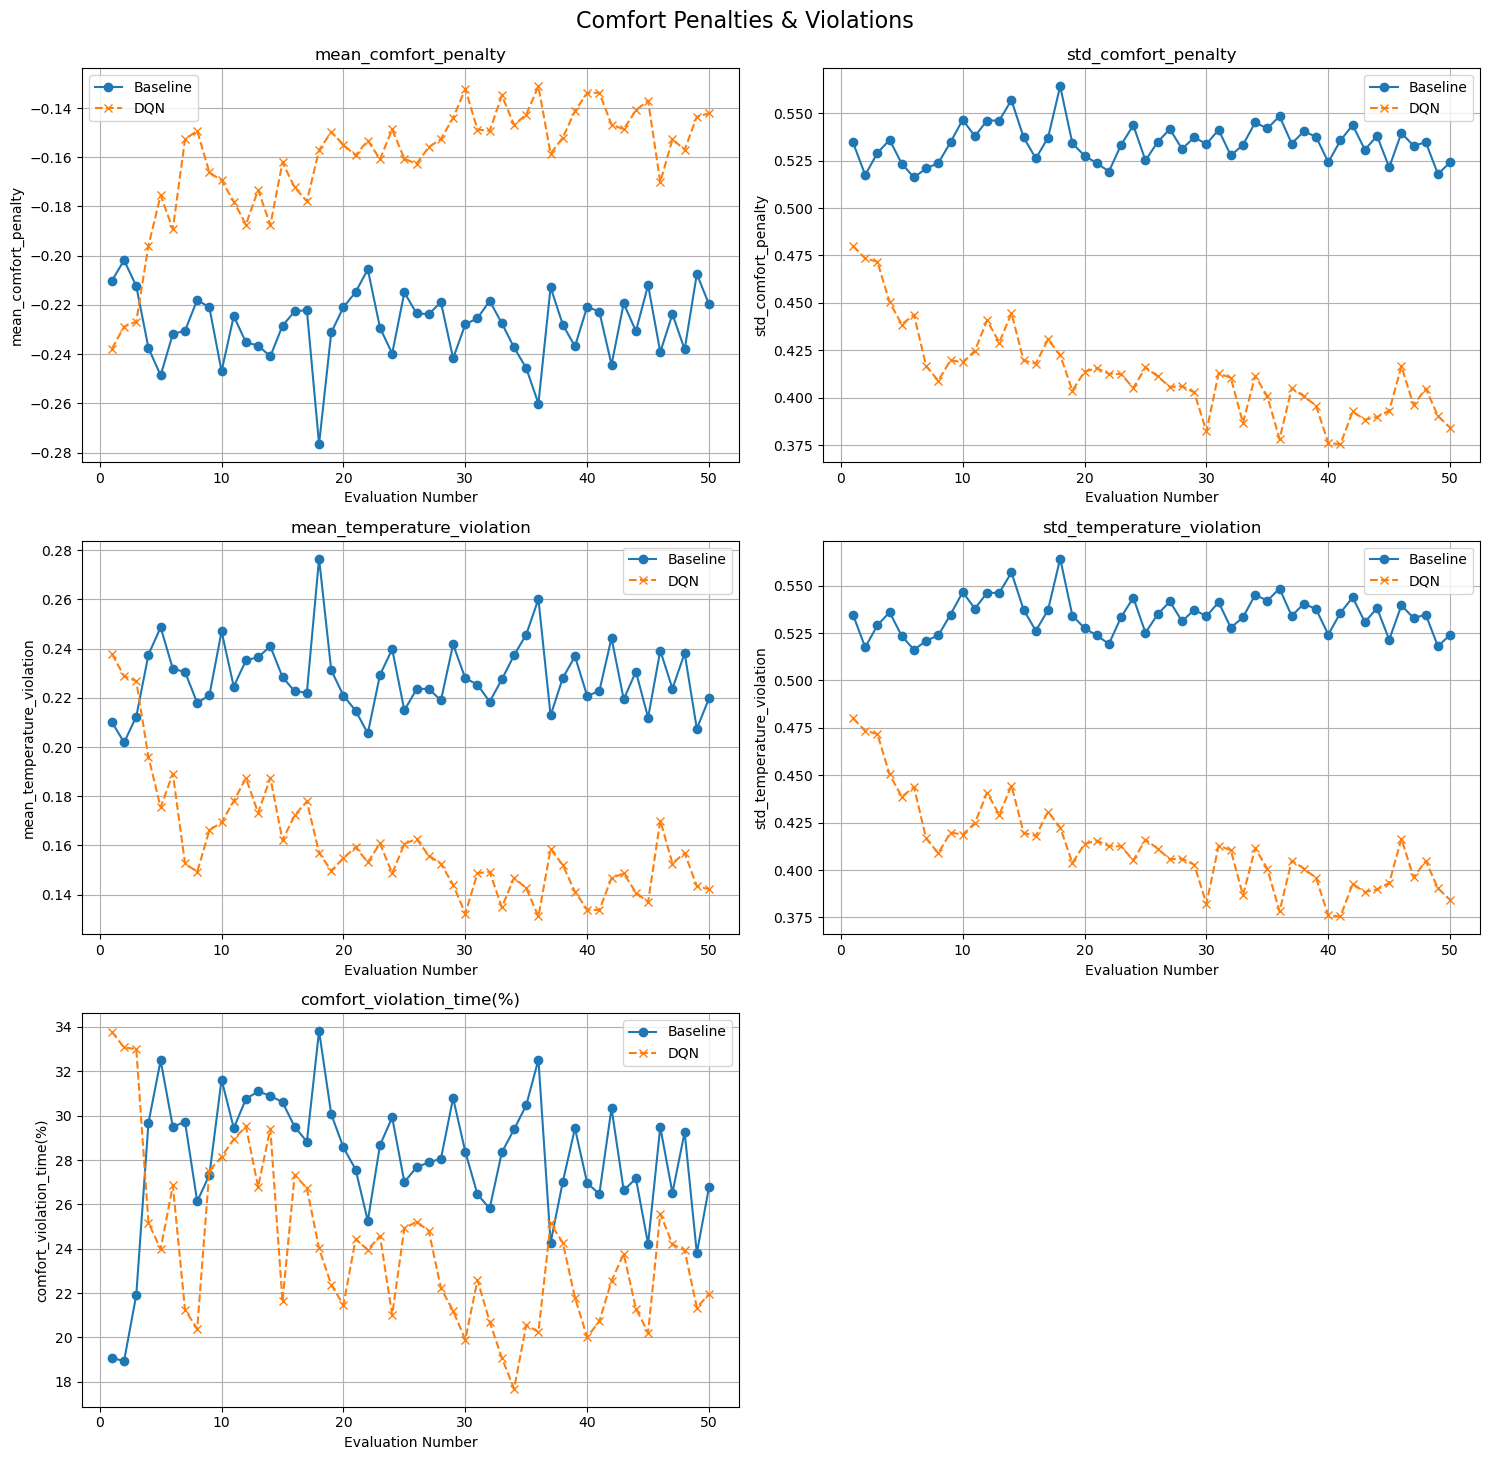

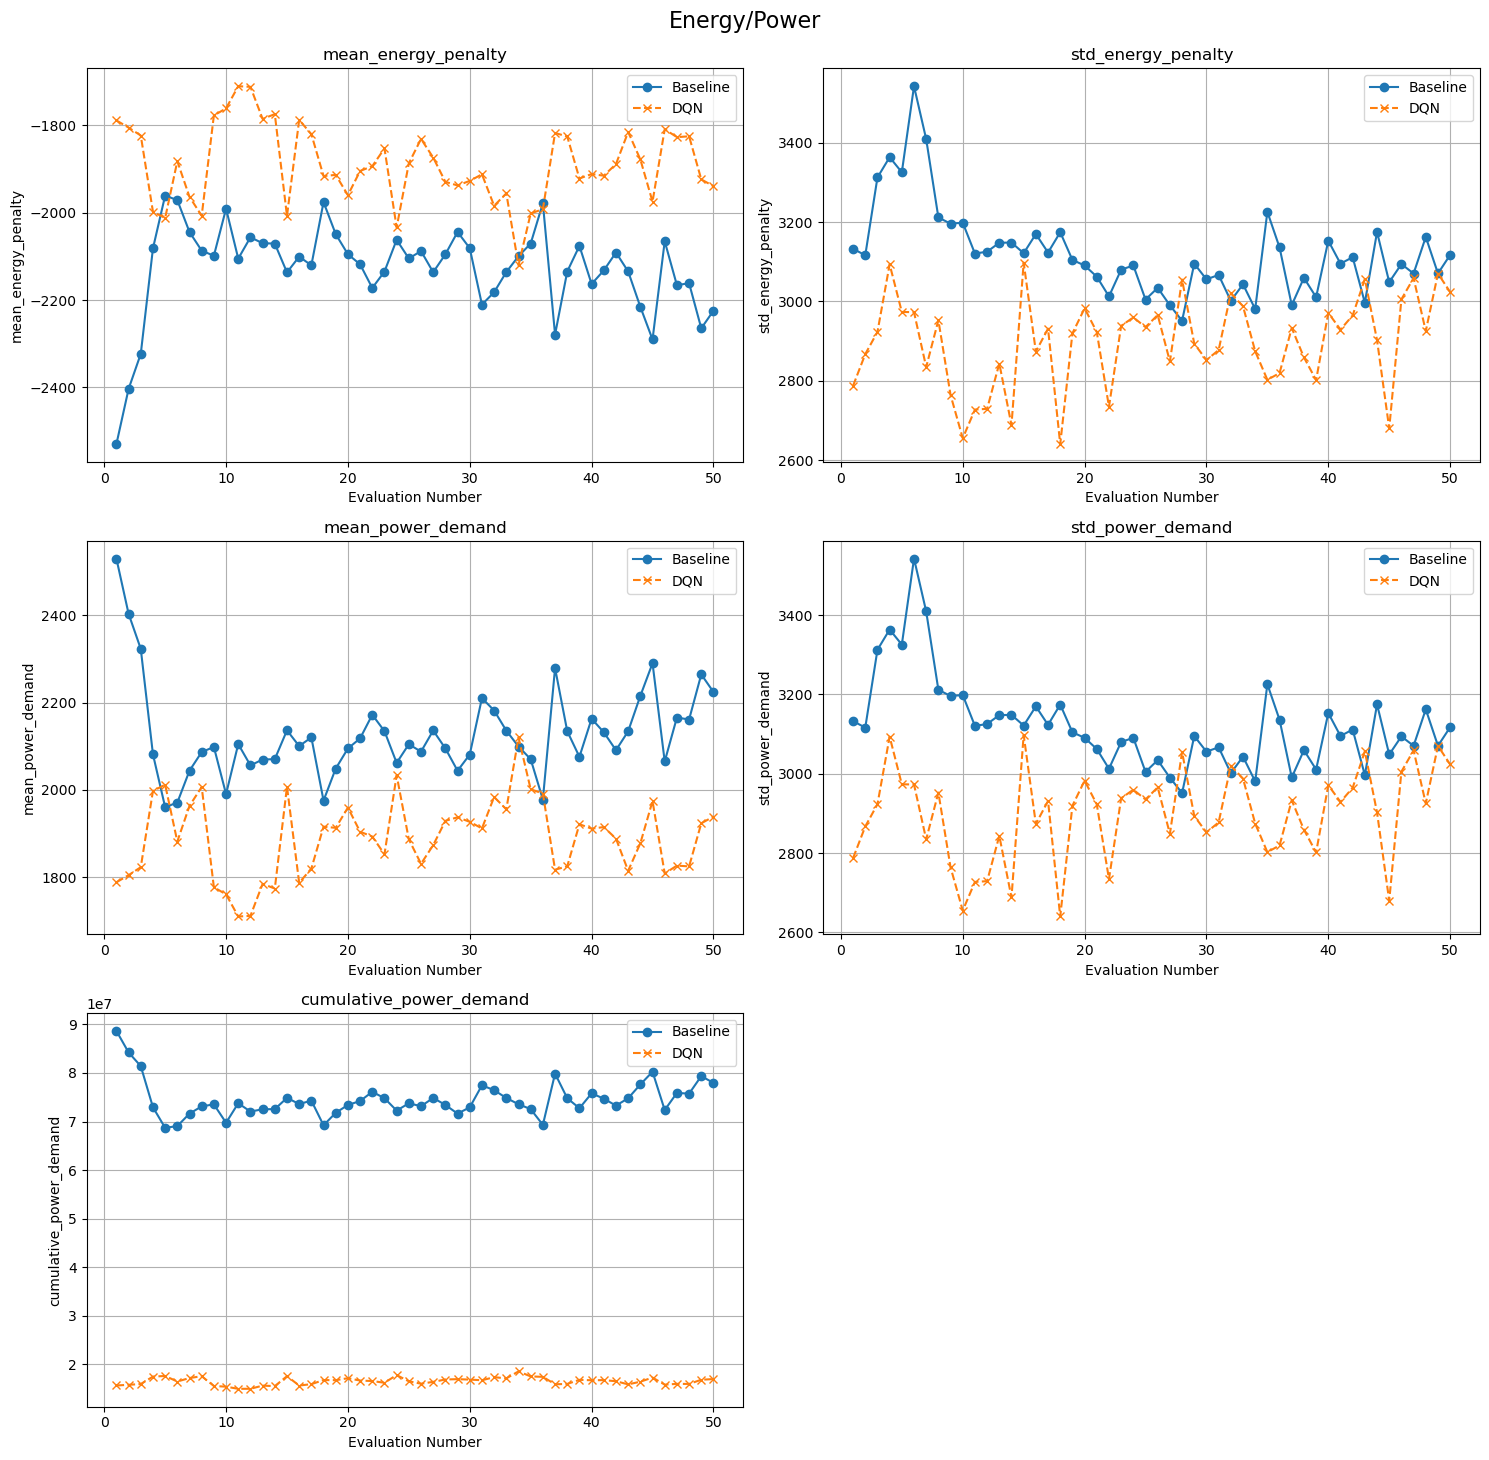

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define paths to the metrics files
# Adjust these paths if the notebook is moved or folders change
baseline_path = '../outputs/Baseline_Training/Baseline_Train-res1/evaluation/evaluation_metrics.csv'
dqn_path = '../outputs/DQN_Training/DQN_Train-res1/evaluation/evaluation_metrics.csv'

# Load the CSV data
try:
    df_baseline = pd.read_csv(baseline_path)
except FileNotFoundError:
    raise ValueError(f"Error: Baseline file not found at {baseline_path}")

try:
    df_dqn = pd.read_csv(dqn_path)
except FileNotFoundError:
    raise ValueError(f"Error: DQN file not found at {dqn_path}")

# Define the categories and metrics to plot
categories = {
    "Reward": [
        'mean_reward', 
        'std_reward'
    ],
    "Reward Components": [
        'mean_reward_comfort_term', 
        'std_reward_comfort_term', 
        'mean_reward_energy_term', 
        'std_reward_energy_term'
    ],
    "Comfort Penalties & Violations": [
        'mean_comfort_penalty', 
        'std_comfort_penalty', 
        'mean_temperature_violation', 
        'std_temperature_violation', 
        'comfort_violation_time(%)'
    ],
    "Energy/Power": [
        'mean_energy_penalty', 
        'std_energy_penalty', 
        'mean_power_demand', 
        'std_power_demand', 
        'cumulative_power_demand'
    ]
}

# Iterate over categories and create subplots
if not df_baseline.empty and not df_dqn.empty:
    for cat_name, cat_metrics in categories.items():
        n = len(cat_metrics)
        rows = (n + 1) // 2
        cols = 2 if n > 1 else 1
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        fig.suptitle(cat_name, fontsize=16)
        
        if n > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
        
        for i, metric in enumerate(cat_metrics):
            if i >= len(axes):
                break
            ax = axes[i]
            
            # Determine x-axis
            if 'evaluation_num' in df_baseline.columns:
                x_base = df_baseline['evaluation_num']
            else:
                x_base = df_baseline.index
            
            if 'evaluation_num' in df_dqn.columns:
                x_dqn = df_dqn['evaluation_num']
            else:
                x_dqn = df_dqn.index

            # Check if metric exists in columns
            if metric in df_baseline.columns:
                ax.plot(x_base, df_baseline[metric], label='Baseline', marker='o', linestyle='-')
            if metric in df_dqn.columns:
                ax.plot(x_dqn, df_dqn[metric], label='DQN', marker='x', linestyle='--')
            
            ax.set_title(metric)
            ax.set_xlabel('Evaluation Number')
            ax.set_ylabel(metric)
            ax.legend()
            ax.grid(True)
            
        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout(rect=[0, 0.01, 1, 0.99])
        plt.show()
else:
    print("Could not plot because one or both dataframes are empty.")